# Three ways evals lie to you — and the statistics that catch them

Eval frameworks are good at producing a score. They are much weaker at answering the question the score exists for: **is system A actually better than system B, and by how much?** This notebook demonstrates the three failure modes that corrupt that answer, on real [GPQA Diamond](https://huggingface.co/datasets/Idavidrein/gpqa) results, using [`evalconfidence`](../README.md):

1. **Wrong winner** — an unpaired comparison buries a real improvement in noise that pairing cancels.
2. **False confidence** — repeated epochs inflate the apparent sample size, so naive intervals are too narrow.
3. **No budget plan** — without power analysis, teams can't know what gap their eval can even detect.

**The data is real:** `inspect eval inspect_evals/gpqa_diamond` on all **198 items × 5 epochs** for two OpenAI models, **gpt-5-nano-2025-08-07** vs **gpt-5.4-mini-2026-03-17** (June 2026, ~\$4 total including pilots). The notebook itself runs from the committed scores-only CSV — no API keys, no HF access needed. Two honesty notes on the setup:

- **Scores here are far below leaderboard numbers** (67.6% / 61.7% vs 80s–90s): leaderboards use provider scaffolds and high reasoning effort; we ran Inspect's stock task at default settings. The pair was chosen from a 4-model, 50-item pilot *because* its measured gap at these settings sits in the statistically interesting zone — and yes, at default settings the older, cheaper nano beats the newer mini.
- **GPQA is QA, not tool use.** The math is indifferent: an item can be a physics question or a SWE-bench task scored success/failure. Everything below applies unchanged to agent trajectories.

## The data

Each row of the CSV is one `ItemResult(item_id, model_id, score, epoch)` — the normalized unit every `evalconfidence` function consumes. `item_id` is the opaque HF record id; the raw Inspect `.eval` logs stay out of the repo because they embed the gated GPQA questions verbatim. To regenerate from scratch (or reproduce the logs locally):

```bash
pip install 'evalconfidence[inspect]' inspect-evals   # + OPENAI_API_KEY, HF terms accepted
inspect eval inspect_evals/gpqa_diamond --model openai/gpt-5-nano-2025-08-07 --epochs 5 --log-dir logs/full
inspect eval inspect_evals/gpqa_diamond --model openai/gpt-5.4-mini-2026-03-17 --epochs 5 --log-dir logs/full
python examples/export_scores.py                      # logs -> scores-only CSV
```

With local logs you'd load `from_inspect("logs/full/....eval")`; here we load the committed CSV with `from_dataframe` — every cell downstream is identical either way.

In [1]:
import pandas as pd

from evalconfidence import from_dataframe, compare, power, standard_error

df = pd.read_csv("data/gpqa_diamond_scores.csv")
results = from_dataframe(df)
nano = [r for r in results if "gpt-5-nano" in r.model_id]
mini = [r for r in results if "gpt-5.4-mini" in r.model_id]

N_ITEMS = len({r.item_id for r in nano})
N_EPOCHS = len({r.epoch for r in nano})
acc = lambda rs: sum(r.score for r in rs) / len(rs)
print(f"{N_ITEMS} items x {N_EPOCHS} epochs per model")
print(f"gpt-5-nano:     {acc(nano):.3f}")
print(f"gpt-5.4-mini:   {acc(mini):.3f}   (observed gap {100*(acc(nano)-acc(mini)):.1f} pts)")

198 items x 5 epochs per model
gpt-5-nano:     0.676
gpt-5.4-mini:   0.617   (observed gap 5.9 pts)


## Figure 1 — Wrong winner: the comparison most teams run vs. the one they should

The standard move is to score each model, put a confidence interval on each, and eyeball the overlap. That is an **unpaired** comparison: its variance is $\mathrm{Var}(A) + \mathrm{Var}(B)$, dominated by *which questions are hard* — variation that has nothing to do with which model is better, and that both models share (PhD-level science questions are hard-for-both or easy-for-both).

A **paired** comparison differences the two models *within each item* before averaging, so shared item difficulty cancels: $\mathrm{Var}(A-B) = \mathrm{Var}(A) + \mathrm{Var}(B) - 2\,\mathrm{Cov}(A,B)$. `compare()` pairs automatically whenever the two systems share items.

In [2]:
paired = compare(nano, mini)                  # pairs on shared item_ids
unpaired = compare(nano, mini, paired=False)  # the eyeball test, formalized

print("--- Unpaired (what most teams do) ---")
print(unpaired)
print()
print("--- Paired (same data) ---")
print(paired)

--- Unpaired (what most teams do) ---
openai/gpt-5-nano-2025-08-07 is estimated to outperform openai/gpt-5.4-mini-2026-03-17 by 5.9 points, 95% CI [-2.1, 13.8] (A−B). The difference is NOT significant at alpha=0.05 (p=0.1486, welch_t).
Note: Epoch repeats were aggregated to per-item mean scores.

--- Paired (same data) ---
openai/gpt-5-nano-2025-08-07 is estimated to outperform openai/gpt-5.4-mini-2026-03-17 by 5.9 points, 95% CI [0.4, 11.3] (A−B). The difference is significant at alpha=0.05 (p=0.0363, paired_t).
Pairing reduced the comparison variance by 2.1x: the 198 paired items deliver the precision of ~420 unpaired items.
Note: Epoch repeats were aggregated to per-item mean scores.


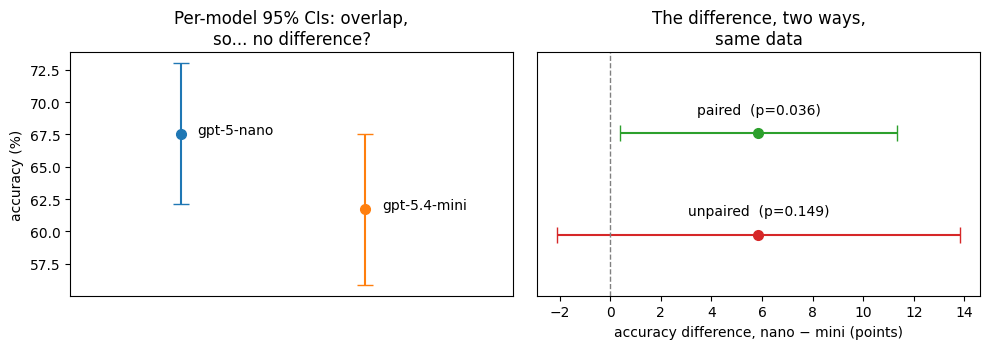

In [3]:
import matplotlib.pyplot as plt

se_nano, se_mini = standard_error(nano), standard_error(mini)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

# Left: the per-model intervals people eyeball.
for x, (label, se) in enumerate([("gpt-5-nano", se_nano), ("gpt-5.4-mini", se_mini)]):
    lo, hi = se.ci
    ax1.errorbar([x], [100 * se.mean], yerr=[[100 * se.mean - 100 * lo], [100 * hi - 100 * se.mean]],
                 fmt="o", capsize=6, markersize=7)
    ax1.annotate(label, (x, 100 * se.mean), xytext=(12, 0), textcoords="offset points")
ax1.set_xlim(-0.6, 1.8); ax1.set_xticks([])
ax1.set_ylabel("accuracy (%)")
ax1.set_title("Per-model 95% CIs: overlap,\nso... no difference?")

# Right: the difference itself, unpaired vs paired, on the same data.
for y, (label, res) in enumerate([("unpaired", unpaired), ("paired", paired)]):
    lo, hi = res.ci_diff
    color = "tab:green" if res.significant else "tab:red"
    ax2.errorbar([100 * res.diff], [y], xerr=[[100 * res.diff - 100 * lo], [100 * hi - 100 * res.diff]],
                 fmt="o", capsize=6, markersize=7, color=color)
    ax2.annotate(f"{label}  (p={res.p_value:.3f})", (100 * res.diff, y),
                 xytext=(0, 14), textcoords="offset points", ha="center")
ax2.axvline(0, color="gray", lw=1, ls="--")
ax2.set_ylim(-0.6, 1.8); ax2.set_yticks([])
ax2.set_xlabel("accuracy difference, nano − mini (points)")
ax2.set_title("The difference, two ways,\nsame data")
fig.tight_layout()

**Takeaway.** Both views come from the *same 1,980 scored responses*. The unpaired comparison spans zero (95% CI [−2.1, +13.8], p = 0.15) — by the usual eyeball test, "no significant difference," and a real 5.9-point edge gets shelved. Pairing differences the models within each question first, cancels the shared item difficulty, and the same data give a verdict: 95% CI [+0.4, +11.3], p = 0.036. The variance-reduction factor was **2.1×** — these 198 paired items deliver the precision of ~420 unpaired items. Pairing is free precision: it only requires running both systems on the same questions, which most teams already do and then throw away at analysis time.

## Figure 2 — False confidence: 990 observations that aren't 990

Running 5 epochs per item is good practice — it averages out per-response randomness. But the 990 resulting observations are **not independent**: the same item's scores repeat that item's difficulty 5 times. A naive standard error divides by $\sqrt{990}$ as if they were, and comes out too small. `standard_error()` reports the naive and cluster-robust numbers side by side, so the gap is visible rather than silent.

In [4]:
se_nano = standard_error(nano)   # clusters by item automatically (epochs detected)
print(se_nano)

# The temperature-0 thought experiment, grounded in the same real data: if all
# 5 epochs had just repeated each item's first answer (zero new information),
# the extra 792 rows would be pure duplication and the design effect = K = 5.
from evalconfidence import ItemResult
first = {(r.item_id): r.score for r in nano if r.epoch == min(e.epoch for e in nano)}
repeats = [ItemResult(item_id=i, model_id="nano-epoch1-repeated", score=s, epoch=k)
           for i, s in first.items() for k in range(N_EPOCHS)]
se_rep = standard_error(repeats)
print(f"\nIdentical-epochs extreme: inflation {se_rep.inflation:.2f}x, "
      f"design effect {se_rep.design_effect:.2f} (theory: exactly {N_EPOCHS})")

Mean score: 0.6758  (n=990 observations)
  Naive i.i.d. SE:    0.0149  ->  95% CI [0.6465, 0.7050]
  Cluster-robust SE:  0.0276  ->  95% CI [0.6213, 0.7302]  (198 clusters by item)
  Inflation: 1.85x  (design effect 3.44)
  The naive interval treats all 990 observations as independent; the cluster-robust interval accounts for dependence within the 198 clusters and is the honest one to report.

Identical-epochs extreme: inflation 2.24x, design effect 5.02 (theory: exactly 5)


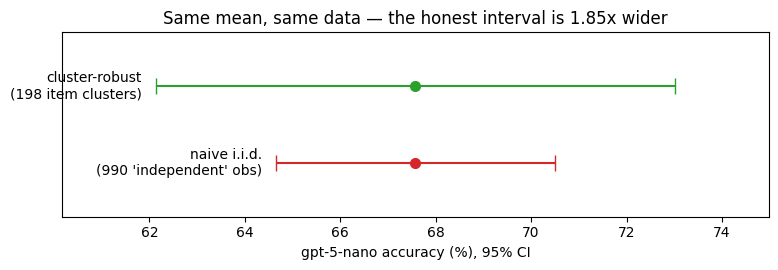

In [5]:
fig, ax = plt.subplots(figsize=(8, 2.8))
rows = [
    ("naive i.i.d.\n(990 'independent' obs)", se_nano.se_naive, se_nano.ci_naive, "tab:red"),
    ("cluster-robust\n(198 item clusters)", se_nano.se_clustered, se_nano.ci_clustered, "tab:green"),
]
for y, (label, se, (lo, hi), color) in enumerate(rows):
    ax.errorbar([100 * se_nano.mean], [y], xerr=[[100 * (se_nano.mean - lo)], [100 * (hi - se_nano.mean)]],
                fmt="o", capsize=6, markersize=7, color=color)
    ax.annotate(label, (100 * lo, y), xytext=(-10, 0), textcoords="offset points",
                ha="right", va="center")
ax.set_ylim(-0.7, 1.7); ax.set_yticks([])
ax.set_xlabel("gpt-5-nano accuracy (%), 95% CI")
ax.set_title(f"Same mean, same data — the honest interval is {se_nano.inflation:.2f}x wider")
ax.margins(x=0.18)
fig.tight_layout()

**Takeaway.** The mean is identical; only the honesty of the interval changes. On real GPQA epochs the within-item correlation inflates the true standard error by **1.85×** (design effect 3.4) over the naive number — a team quoting the narrow interval will call ~1.9×-too-small differences "significant" and ship false wins at a real α far above the nominal 5%. The limiting case makes the mechanism unmistakable: had every epoch repeated the first answer (what temperature 0 does), the design effect comes out at **5.0 = K**, because 792 of the 990 rows carry zero information. Epochs are not free sample size; they only buy precision on the within-item noise.

## Figure 3 — Budget planning: what can this eval even see?

The two failures above are diagnosed after the money is spent. `power()` works *before*: given the variance from a pilot (or a baseline guess), it answers how many items are needed to detect a target gap (`mde` → `n`), or the smallest gap detectable at a given size (`n` → `mde`), or the achieved power when both are fixed.

It earned its keep in this very notebook: a 50-item pilot of four models showed our first-choice pair (gap 4.0 pts) would have had **27% power** at 198 items — a coin-flip eval costing real money. `power()` rejected it before the spend; the pair you've been reading about was selected because its pilot gap cleared the detectable threshold.

In [6]:
plan_unpaired = power(nano, n=N_ITEMS)            # one-system pilot -> two-arm plan
plan_paired = power((nano, mini), n=N_ITEMS)      # paired pilot -> paired plan
print(plan_unpaired)
print()
print(plan_paired)
print()
print(power((nano, mini), mde=paired.diff, n=N_ITEMS))  # how lucky was Fig 1?

With 198 unpaired items, the minimum detectable gap at alpha=0.05 and 80% power is 10.9 points.
Per-item comparison variance: 0.3016.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a single-system pilot of 198 items; planning a two-arm unpaired comparison (n = items per arm, variance doubled for the second arm). A paired design would need fewer.

With 198 paired items, the minimum detectable gap at alpha=0.05 and 80% power is 7.8 points.
Per-item comparison variance: 0.1529.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a paired pilot of 198 shared items.

With 198 paired items, a true gap of 5.9 points is detected with 56% power at alpha=0.05 (target was 80%).
Per-item comparison variance: 0.1529.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a paired pilot of 198 shared items.


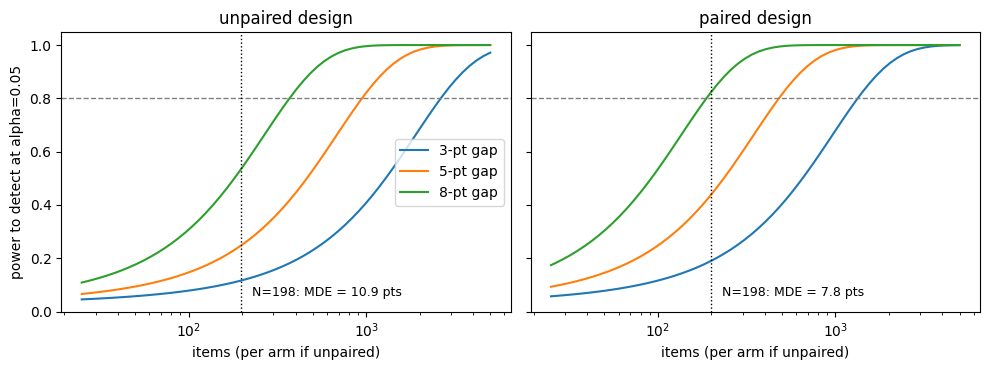

In [7]:
import numpy as np

gaps = [0.03, 0.05, 0.08]
ns = np.unique(np.geomspace(25, 5000, 60).astype(int))
designs = [("unpaired design", plan_unpaired.variance),
           ("paired design", plan_paired.variance)]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (name, var) in zip(axes, designs):
    for gap in gaps:
        curve = [power(baseline_var=var, mde=gap, n=int(n)).power_achieved for n in ns]
        ax.plot(ns, curve, label=f"{100 * gap:.0f}-pt gap")
    ax.axhline(0.8, color="gray", lw=1, ls="--")
    ax.axvline(N_ITEMS, color="black", lw=1, ls=":")
    mde_n = power(baseline_var=var, n=N_ITEMS).mde_detectable
    ax.annotate(f"N=198: MDE = {100 * mde_n:.1f} pts", (N_ITEMS, 0.06),
                xytext=(8, 0), textcoords="offset points", fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("items (per arm if unpaired)")
    ax.set_title(name)
axes[0].set_ylabel("power to detect at alpha=0.05")
axes[0].legend(loc="center right")
fig.tight_layout()

**Takeaway.** Most people are surprised by the left panel: at GPQA Diamond's size, an **unpaired** comparison can only detect a **10.9-point** accuracy gap at 80% power — a 5-point improvement needs ~1,000 items per arm. Nobody's 198-item leaderboard delta of "+3 points" means much unpaired. Pairing (right panel) drops the minimum detectable gap at N=198 to **7.8 points**. And it scores this notebook's own Figure 1 honestly: the observed 5.9-point paired win had just **56% power** — a coin flip that landed well. The fix is exactly what `power()` prints: detecting ~6 points reliably needs ~350 paired items, and that is a budget line you can compute *before* the run, not an excuse after it.

## Closing the loop

One real dataset, three corrections, and the four questions a decision needs answered:

| Question | Answer here | Function |
|---|---|---|
| Which system is better? | gpt-5-nano, by 5.9 pts, 95% CI [+0.4, +11.3] | `compare()` |
| How confident should I be? | p = 0.036 *paired*; unpaired the same data say p = 0.15 | `compare()` |
| How much confidence is dependence-inflated? | naive SE is 1.85× too small (DEFF 5 = K if epochs were identical) | `standard_error()` |
| How many items do I actually need? | MDE@198: 10.9 pts unpaired / 7.8 paired; ~6 pts reliably → ~350 paired items | `power()` |

All of it runs on results you already have — `from_inspect()` for Inspect AI logs, `from_dataframe()` for anything tabular — with no model calls and no framework lock-in.